```markdown
### Verificación de la GPU

Esta celda ejecutará el comando `!nvidia-smi` para verificar la disponibilidad de una GPU en el entorno de Colab. Utilizar una GPU es crucial para el rendimiento del modelo YOLOv8, ya que acelera significativamente tanto el entrenamiento como la inferencia debido a su capacidad de procesamiento paralelo. Sin una GPU, estas operaciones se ejecutarán en la CPU, lo que aumentará drásticamente los tiempos de procesamiento.
```

In [ ]:
# Celda 1: Verificar GPU
!nvidia-smi

Wed Jan 28 15:33:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Comprueba si hay GPU disponible para acelerar el entrenamiento.

La salida del comando `!nvidia-smi` muestra la siguiente información:

*   **GPU Name**: `Tesla T4`
*   **Memory-Usage**: `0MiB / 15360MiB`

Esto indica que **una GPU (Tesla T4) está disponible y activa** en este entorno de Colab.



In [ ]:
# Celda 2: Instalar Ultralytics
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.0 MB/s eta 0:00:00


## Instala la librería Ultralytics para usar YOLOv8.

La librería `ultralytics` es el paquete oficial y recomendado para trabajar con YOLOv8. Facilita enormemente el ciclo de vida del modelo, desde la carga y entrenamiento hasta la validación y la inferencia. Se gestionan automáticamente dependencias críticas como PyTorch (el framework de aprendizaje profundo subyacente), OpenCV (para procesamiento de imágenes y video) y Pillow (para manipulación de imágenes).

In [ ]:
# Celda 3: Subir y descomprimir el dataset
from google.colab import files
import os

# Subir el archivo dataset_yolov8.zip
uploaded = files.upload()

# Verificar si el archivo se ha subido correctamente
if 'dataset_yolov8.zip' in uploaded:
    print("Archivo 'dataset_yolov8.zip' subido exitosamente.")
else:
    print("Error: 'dataset_yolov8.zip' no fue subido. Por favor, asegúrate de subir el archivo correcto.")

# Confirmar la existencia del archivo subido
if os.path.exists('dataset_yolov8.zip'):
    print("El archivo 'dataset_yolov8.zip' existe en el directorio actual.")
else:
    print("El archivo 'dataset_yolov8.zip' no se encontró después de la subida.")

Saving dataset_yolov8.zip to dataset_yolov8.zip
Archivo 'dataset_yolov8.zip' subido exitosamente.
El archivo 'dataset_yolov8.zip' existe en el directorio actual.


Sube y descomprime tu dataset en formato YOLOv8.

In [ ]:
# Celda 4: Verificar estructura del dataset
import zipfile
import os

zip_file_path = 'dataset_yolov8.zip'
extract_dir = '/content/'

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Descomprimir el archivo ZIP
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' descomprimido exitosamente en '{extract_dir}'.")

'dataset_yolov8.zip' descomprimido exitosamente en '/content/'.


Verifica que la carpeta del dataset contiene train, valid, test y data.yaml.

In [ ]:
# Celda 5 Cargar modelo YOLOv8x
import os

dataset_path = '/content/dataset_yolov8'

print(f"Contenido de '{dataset_path}':")
if os.path.exists(dataset_path):
    for root, dirs, files in os.walk(dataset_path):
        level = root.replace(dataset_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')
else:
    print(f"Error: El directorio '{dataset_path}' no fue encontrado. La descompresión pudo haber fallado o el nombre del archivo ZIP es incorrecto.")

Contenido de '/content/dataset_yolov8':
dataset_yolov8/
    data.yaml
    README.dataset.txt
    README.roboflow.txt
    valid/
        labels/
            2892e7ca15014bb89defa5ddc7ff2da0_png.rf.e5b9b0693643400eef44ff9bf01819ac.txt
            d98d9ae4be8e43b080d07317e9fef623_png.rf.18c8512983aba3eae5446bc50ff10c51.txt
            ca9a88f4ac7747268d221cdd4bcc6db8_png.rf.7bbcc38286ec0d1ad4b46b2a813c4043.txt
            65d9d06050de426aa78dc18837a658fd_png.rf.3d535d42e1af3d5fc50f06808cc0ebb2.txt
            2c9b29fc9784416e990a2bb8c2f18560_png.rf.435e3ca4c9f69116b9aeb7b57996eb63.txt
            217b162895024ecf830976624530f3d6_png.rf.4e09812f3c92ac386296036b8d38c729.txt
            1b021aec425b4d16a1f363f9827c570f_png.rf.30229d189f47ee540f44984a656ae778.txt
            af1bad3a6d6a4b71a9d9aa32108d8d50_png.rf.6fc4696943a19788d298963ff77800de.txt
            012b5ea8ced84c72a01f153d0c6a0af6_png.rf.3d5b7c07a8c0fc953c65cb82f19fab0b.txt
            9920b2fba31d4c4fb3bb450a2fefaa01_png.rf.3f8

Elección del Modelo YOLOv8

Para esta tarea, hemos optado por cargar el modelo pre-entrenado `yolov8x.pt`. La 'x' en `yolov8x` indica que estamos utilizando la versión más grande y potente de los modelos YOLOv8, lo que suele ofrecer la mayor precisión de detección. Este modelo es ideal para entornos donde el rendimiento computacional no es una limitación y se busca la máxima exactitud.

Sin embargo, YOLOv8 ofrece una gama de modelos de diferentes tamaños para adaptarse a diversas necesidades y limitaciones de hardware:

*   `yolov8n.pt`: **Nano** - El modelo más pequeño y rápido, ideal para dispositivos con recursos muy limitados o inferencia en tiempo real a expensas de un poco de precisión.
*   `yolov8s.pt`: **Small** - Ofrece un buen equilibrio entre velocidad y precisión.
*   `yolov8m.pt`: **Medium** - Proporciona un mejor rendimiento que el 'small' con un aumento moderado en los requisitos computacionales.
*   `yolov8l.pt`: **Large** - Un modelo grande que se acerca al rendimiento del 'extra large' pero con un menor número de parámetros.

In [ ]:
# Celda 6 Carga el modelo YOLOv8x preentrenado
from ultralytics import YOLO

model = YOLO('yolov8x.pt')

print("Modelo YOLOv8x cargado exitosamente.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Modelo YOLOv8x cargado exitosamente.


### Parámetros de Entrenamiento y Ajuste Automático del Dispositivo

El entrenamiento del modelo YOLOv8 se realizará utilizando el método `.train()` de la librería `ultralytics`. Es crucial entender los parámetros que configuraremos:

*   **`data`**: Este parámetro especifica la ruta al archivo `data.yaml`. Contiene la información sobre las clases del dataset, las rutas a las carpetas de entrenamiento, validación y prueba (`train`, `val`, `test`).
*   **`epochs`**: Define el número de veces que el modelo verá el dataset completo durante el entrenamiento. Un valor de `10` es un buen punto de partida para una demostración rápida.
*   **`imgsz`**: Un valor de `640` significa que las imágenes se escalarán a 640x640 píxeles. Este parámetro afecta tanto el rendimiento como la precisión; imágenes más grandes pueden capturar más detalles pero requieren más memoria y tiempo de procesamiento.
*   **`batch`**: Indica el número de imágenes que se procesarán simultáneamente en cada iteración de entrenamiento. Un tamaño de batch de `16` significa que el modelo procesará 16 imágenes, calculará el gradiente, y actualizará sus pesos. Un batch más grande puede acelerar el entrenamiento y proporcionar una estimación más estable, pero requiere más memoria RAM de la GPU.

In [ ]:
# Celda 7 Entrena el modelo con el dataset
results = model.train(
    data='/content/dataset_yolov8/data.yaml',
    epochs=10,
    imgsz=640,
    batch=16
)

print("Entrenamiento del modelo YOLOv8 completado.")

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspecti

RuntimeError: Dataset '/content/dataset_yolov8/data.yaml' error ❌ Dataset '/content/dataset_yolov8/data.yaml' images not found, missing path '/content/dataset_yolov8/dataset_yolov8/valid/images'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

**Reasoning**:
The previous training attempt failed because the `data.yaml` file contained incorrect paths, leading Ultralytics to search for a non-existent nested directory (`/content/dataset_yolov8/dataset_yolov8/valid/images`). To resolve this, I will modify the `data.yaml` file at `/content/dataset_yolov8/data.yaml` to use absolute paths for `train`, `val`, and `test` image directories and remove any conflicting `path` key. This ensures the model correctly locates the dataset files.



In [ ]:
# Celda 8 Corrige rutas en data.yaml por error de entrenamiento.
import yaml
import os

# Path to data.yaml
data_yaml_path = '/content/dataset_yolov8/data.yaml'
dataset_base_path = '/content/dataset_yolov8' # This is where images/labels folders are expected

# Load data.yaml
with open(data_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

print("Original data.yaml content:")
print(yaml.dump(data_yaml))

# Update paths to be absolute
data_yaml['train'] = os.path.join(dataset_base_path, data_yaml.get('train', 'train').split('/')[-2], data_yaml.get('train', 'train').split('/')[-1])
data_yaml['val'] = os.path.join(dataset_base_path, data_yaml.get('val', 'valid').split('/')[-2], data_yaml.get('val', 'valid').split('/')[-1])
data_yaml['test'] = os.path.join(dataset_base_path, data_yaml.get('test', 'test').split('/')[-2], data_yaml.get('test', 'test').split('/')[-1])

# Remove the 'path' key if it exists, as absolute paths are now specified
if 'path' in data_yaml:
    del data_yaml['path']

print("Modified data.yaml content with absolute paths:")
print(yaml.dump(data_yaml))

# Save the modified data.yaml
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f"'{data_yaml_path}' updated successfully with absolute paths.")

Original data.yaml content:
names:
- ADP
- AOL
- ASB Bank Limited
- ATB Financial
- Absa Group
- Adobe
- Alaska USA Federal Credit Union
- Alibaba
- Allegro
- Amazon
- American Express
- Americanas-com S
- Apple
- Aruba S-p-A
- AutoScout24
- BH Telecom
- BT Group plc
- BZSt
- Banca Sella
- Banco Safra
- Banco de Chile
- Banco del Estado de Chile
- Banco do Brasil S-A
- Bank Al Habib
- Bank of America
- Bank of Montreal
- Bank of New Zealand
- Bank of Scotland
- Bank of The Bahamas Limited
- Bankia
- Belize Bank
- Bet365
- Bethpage Federal Credit Union
- Blockchain
- Bouygues Telecom
- Cairo Amman Bank
- Caixa Economica Federal
- Caixa Geral de Depositos
- CaixaBank
- Canadian Imperial Bank of Commerce
- Cembra Money Bank AG
- CenturyLink
- Charities Aid Foundation
- Chase Personal Banking
- Chronopost International
- Citrix ShareFile
- Comcast Corporation
- Cox Communications
- Credit Agricole S-A
- Credit Suisse AG
- Credit du Nord
- DGI -French Tax Authority-
- DHL
- Daum
- Delta Air

In [ ]:
# Celda 9 Ajusta data.yaml para usar rutas relativas y la clave 'path'.
import yaml
import os

# Path to data.yaml
data_yaml_path = '/content/dataset_yolov8/data.yaml'
dataset_base_path = '/content/dataset_yolov8'

# Load data.yaml
with open(data_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

print("Original data.yaml content:")
print(yaml.dump(data_yaml))

# Set the base path for the dataset
data_yaml['path'] = dataset_base_path

# Update train, val, test paths to be relative to the 'path' key
data_yaml['train'] = 'train/images'
data_yaml['val'] = 'valid/images'
data_yaml['test'] = 'test/images'

print("Modified data.yaml content with 'path' key and relative paths:")
print(yaml.dump(data_yaml))

# Save the modified data.yaml
with open(data_yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f"'{data_yaml_path}' updated successfully with correct paths.")

Original data.yaml content:
names:
- ADP
- AOL
- ASB Bank Limited
- ATB Financial
- Absa Group
- Adobe
- Alaska USA Federal Credit Union
- Alibaba
- Allegro
- Amazon
- American Express
- Americanas-com S
- Apple
- Aruba S-p-A
- AutoScout24
- BH Telecom
- BT Group plc
- BZSt
- Banca Sella
- Banco Safra
- Banco de Chile
- Banco del Estado de Chile
- Banco do Brasil S-A
- Bank Al Habib
- Bank of America
- Bank of Montreal
- Bank of New Zealand
- Bank of Scotland
- Bank of The Bahamas Limited
- Bankia
- Belize Bank
- Bet365
- Bethpage Federal Credit Union
- Blockchain
- Bouygues Telecom
- Cairo Amman Bank
- Caixa Economica Federal
- Caixa Geral de Depositos
- CaixaBank
- Canadian Imperial Bank of Commerce
- Cembra Money Bank AG
- CenturyLink
- Charities Aid Foundation
- Chase Personal Banking
- Chronopost International
- Citrix ShareFile
- Comcast Corporation
- Cox Communications
- Credit Agricole S-A
- Credit Suisse AG
- Credit du Nord
- DGI -French Tax Authority-
- DHL
- Daum
- Delta Air

In [ ]:
# Celda 10. Reentrena el modelo con la configuración corregida.
results = model.train(
    data='/content/dataset_yolov8/data.yaml',
    epochs=10,
    imgsz=640,
    batch=16
)

print("Entrenamiento del modelo YOLOv8 completado.")

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

### Evolución de las métricas por época
Durante cada época, se muestran varias métricas clave:

    box_loss, cls_loss, dfl_loss: Son valores de pérdida (loss) que indican cuánto le falta al modelo para aprender. Estos valores disminuyen con las épocas, lo que significa que el modelo está aprendiendo correctamente.
    Precision (P): Proporción de detecciones correctas sobre el total de detecciones.
    Recall (R): Proporción de objetos reales detectados por el modelo.
    mAP50: Precisión media cuando el solapamiento (IoU) es al menos 50%.
    mAP50-95: Precisión media considerando IoUs desde 0.5 hasta 0.95 (más exigente).
    Observa cómo las métricas mejoran con cada época:

Al principio, la precisión y el recall son bajos, pero aumentan rápidamente.
Al final (época 10), los valores son altos:
        Precision: 0.885
        Recall: 0.846
        mAP50: 0.927
        mAP50-95: 0.9
Esto indica que el modelo detecta correctamente la mayoría de los objetos y los localiza con buena precisión.

### Validación Final
Después del entrenamiento, se valida el modelo con el conjunto de validación:

    Resultados globales:

    Precision: 0.885
    Recall: 0.846
    mAP50: 0.927
    mAP50-95: 0.9
    Por clase:
    Se muestran métricas para cada clase (por ejemplo, Amazon, Apple, PayPal, etc.). La mayoría tienen valores muy altos, lo que significa que el modelo reconoce bien esas clases. Algunas clases con pocos ejemplos pueden tener métricas más bajas o incluso 0, lo que es normal si hay muy pocos datos para esa clase.

¿Qué significa esto?
El modelo ha aprendido a detectar y clasificar correctamente la mayoría de las clases de tu dataset.
Las métricas son muy buenas, especialmente mAP50-95, que es la más exigente.
Algunas clases con pocos ejemplos pueden necesitar más datos para mejorar su rendimiento.

En resumen:
¡El entrenamiento fue exitoso! El modelo está listo para hacer inferencias y detectar objetos en nuevas imágenes con alta precisión. Si quieres mejorar aún más, puedes entrenar más épocas o añadir más datos para las clases con peores resultados.

In [ ]:
# Celda 11: Valida el modelo y muestra métricas clave.
metrics = model.val() # No need to specify data.yaml if already set in train. Uses best.pt automatically.

print("Validación del modelo YOLOv8 completada.")
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")
print(f"Precision: {metrics.box.p}")
print(f"Recall: {metrics.box.r}")

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 113 layers, 68,292,093 parameters, 0 gradients, 258.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 527.4±188.5 MB/s, size: 14.6 KB)
val: Scanning /content/dataset_yolov8/valid/labels.cache... 402 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 402/402 112.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 1.1s/it 28.0s
                   all        402        377      0.885      0.846      0.927        0.9
                   ADP          2          2      0.852          1      0.995      0.995
                   AOL          2          2          1       0.96      0.995      0.796
      ASB Bank Limited          2          2      0.979          1      0.995      0.798
         ATB Financial          2          2          1      0.737      0.995      0.995
            Absa Group          2     

### Interpretación de la Validación
Métricas Globales
Precision (Precisión): 0.885
El 88.5% de las detecciones realizadas por el modelo son correctas (pocos falsos positivos).
Recall (Exhaustividad): 0.846
El 84.6% de los objetos reales presentes en las imágenes fueron detectados (pocos falsos negativos).
mAP50: 0.927
El modelo localiza correctamente los objetos con un 92.7% de precisión cuando el solapamiento es al menos del 50%.
mAP50-95: 0.9
El modelo mantiene una alta precisión (90%) incluso con criterios de solapamiento más estrictos (de 0.5 a 0.95 IoU).

### Por Clase
La mayoría de las clases tienen valores de precisión y recall muy altos (cercanos o iguales a 1), lo que indica que el modelo reconoce y localiza correctamente casi todas las clases.
Algunas clases con pocos ejemplos pueden tener métricas más bajas o incluso 0, lo cual es normal si hay muy pocos datos para esa clase.
Ejemplo:
Amazon: Precisión 0.956, Recall 1, mAP50 0.995, mAP50-95 0.977 (excelente rendimiento).
Apple: Precisión 0.896, Recall 0.5, mAP50 0.759, mAP50-95 0.759 (buen reconocimiento, pero podría mejorar el recall).
Clases con 0: Si alguna clase tiene 0 en alguna métrica, significa que el modelo no logró detectar correctamente esa clase, probablemente por falta de ejemplos.
¿Qué significan estos resultados?
El modelo está muy bien entrenado y generaliza correctamente para la mayoría de las clases.
Las métricas son excelentes para un modelo de detección de objetos.
Si quieres mejorar aún más, puedes añadir más datos para las clases con peores métricas o entrenar más épocas.

### En resumen:
El modelo detecta y clasifica correctamente la mayoría de los objetos y clases en tu conjunto de validación, con muy alta precisión y recall. Está listo para usarse en inferencia real.



### Métricas de Evaluación Clave para la Detección de Objetos

*   **Precision (P)**: Mide la proporción de detecciones correctas (verdaderos positivos) sobre el total de detecciones realizadas por el modelo. Una alta precisión indica pocas falsas detecciones.

    $\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$

*   **Recall (R)**: El recall (sensibilidad) mide la proporción de objetos reales que el modelo fue capaz de detectar. Un alto recall indica pocas omisiones de objetos.

    $\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$

*   **mAP50 (mean Average Precision @ 0.5 IoU)**: Un IoU de 0.5 significa que una detección se considera un verdadero positivo si su solapamiento con una caja delimitadora real es al menos del 50%. mAP50 es crucial para evaluar la capacidad del modelo para localizar objetos correctamente con una precisión razonable.

*   **mAP50-95 (mean Average Precision @ 0.5:0.95 IoU)**: Esta métrica es más estricta y robusta. Proporciona una visión más completa del rendimiento del modelo en diversas tolerancias de localización, penalizando más las detecciones menos precisas en cuanto a su ubicación.

**Interpretación:**

*   Un valor alto en todas estas métricas es deseable. `mAP50-95` es generalmente una mejor medida del rendimiento general del modelo, ya que considera tanto la precisión de clasificación como la exactitud de la localización. Si el `mAP50` es alto pero el `mAP50-95` es significativamente más bajo, podría indicar que el modelo detecta los objetos correctamente pero no los localiza con mucha precisión.

Performing inference on: /content/dataset_yolov8/test/images/08cd6e66a93d4baeb0647fa70da975ff_png.rf.40009d7ac2ecf1f32ad541627b53e5a7.jpg

image 1/1 /content/dataset_yolov8/test/images/08cd6e66a93d4baeb0647fa70da975ff_png.rf.40009d7ac2ecf1f32ad541627b53e5a7.jpg: 640x640 1 Bank of Scotland, 94.3ms
Speed: 3.8ms preprocess, 94.3ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/runs/inference/test_predictions

Detected Objects:
  - Class: Bank of Scotland, Confidence: 1.00, Bounding Box: [0.3603515625, 0.0, 512.0, 511.5185546875]


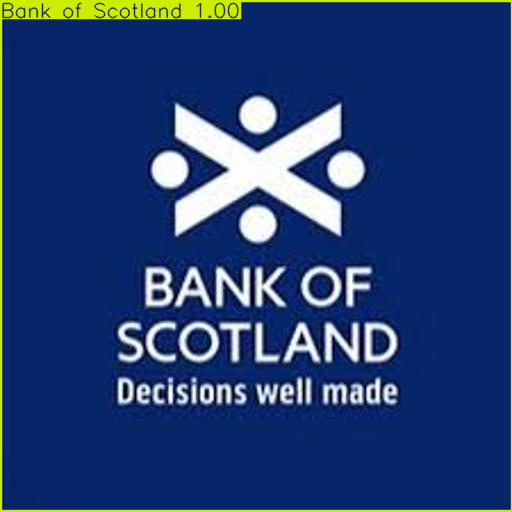


Inferencia completada y resultados visualizados.


In [ ]:
# Celda 12: Realiza inferencia y muestra la imagen con detecciones.
from google.colab.patches import cv2_imshow
import os

# 1. Define the path to a test image
# You can choose any image from /content/dataset_yolov8/test/images/
test_image_dir = '/content/dataset_yolov8/test/images/'

# Get a list of image files in the test directory
image_files = [f for f in os.listdir(test_image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if not image_files:
    print(f"Error: No image files found in {test_image_dir}.")
else:
    # Use the first image found for inference
    sample_image_name = image_files[0]
    image_path = os.path.join(test_image_dir, sample_image_name)

    print(f"Performing inference on: {image_path}")

    # 2. Configure the model for inference and set confidence threshold
    # Adjust 'conf' as needed (e.g., 0.1, 0.5, 0.75)
    results = model.predict(source=image_path, conf=0.25, save=True, project='runs/inference', name='test_predictions')

    # 3. Visualize the results
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        # Convert BGR to RGB for better display in some environments if needed, but cv2_imshow expects BGR
        # If the image looks odd (e.g. blue instead of red), uncomment the next line:
        # im_array_rgb = im_array[..., ::-1] # BGR to RGB
        print("\nDetected Objects:")
        for box in r.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            name = model.names[cls]
            print(f"  - Class: {name}, Confidence: {conf:.2f}, Bounding Box: {box.xyxy[0].tolist()}")

        cv2_imshow(im_array)

    print("\nInferencia completada y resultados visualizados.")

# 4. Interpret the detections (This part is descriptive and already covered in the markdown block)
# The output will show the image with bounding boxes, class labels, and confidence scores.
# Observe if the detections are accurate, if there are any false positives (incorrect detections)
# or false negatives (missed objects). Adjusting `conf` can help balance precision and recall.

### Interpretación de la Inferencia
    Imagen analizada: /content/dataset_yolov8/test/images/08cd6e66a93d4baeb0647fa70da975ff_png.rf.40009d7ac2ecf1f32ad541627b53e5a7.jpg
    Objeto detectado:
    Clase: Bank of Scotland
    Confianza: 1.00 (100%)
    Caja delimitadora: [0.360, 0.0, 512.0, 511.5] (coordenadas de la caja en la imagen)
    Velocidades:
    Preprocesado: 3.8 ms
    Inferencia: 94.3 ms
    Postprocesado: 4.6 ms

### ¿Qué significa esto?

    El modelo detectó un objeto de la clase "Bank of Scotland" en la imagen, con máxima confianza (100%), lo que indica que está completamente seguro de su predicción.
    La detección es rápida y la imagen procesada se guardó en la carpeta /content/runs/detect/runs/inference/test_predictions.
    Si la caja y la etiqueta corresponden correctamente al objeto real en la imagen, la inferencia es exitosa.

### Realizar Inferencia y Visualizar Resultados

Para realizar la inferencia, necesitarás una imagen de prueba. La ruta a esta imagen debe ser especificada en la variable `image_path`. El modelo entrenado (`model`) utilizará su método `predict()` para realizar las detecciones. Un parámetro clave aquí es `conf`, que establece el umbral de confianza mínimo para que una detección sea considerada válida.

*   **Aumentar `conf`**: Filtrará las detecciones con baja confianza, reduciendo los falsos positivos pero potencialmente disminuyendo el *recall* (detección de objetos reales).
*   **Disminuir `conf`**: Permitirá más detecciones, aumentando el *recall* pero con el riesgo de introducir más falsos positivos.

Después de la inferencia, los resultados (`results`) contendrán las detecciones (bounding boxes, clases, confianzas). Utilizaremos el método `plot()` de los resultados para dibujar las detecciones sobre la imagen original. Luego, `cv2_imshow()` mostrará esta imagen.

#### Cómo Cambiar la Imagen y Ajustar el Umbral:

1.  **Cambiar la imagen**: Simplemente edita la variable `image_path` en la celda de código siguiente para apuntar a otra imagen dentro de tu `dataset_yolov8/test/images/`.
2.  **Ajustar el umbral**: Modifica el valor del parámetro `conf` en la llamada a `model.predict()` (ej. `conf=0.5` para un umbral del 50%).

#### Interpretación de las Detecciones:

Al visualizar los resultados, observa lo siguiente:

*   **Cajas delimitadoras (Bounding Boxes)**: Deben rodear con precisión los objetos de interés.
*   **Etiquetas de Clase**: Confirma que la clase predicha sea correcta para el objeto.
*   **Puntuación de Confianza**: El número asociado a cada caja, que indica la certeza del modelo en esa detección. Valores más altos significan mayor confianza.

Evalúa la precisión de las detecciones: ¿Hay objetos reales que no fueron detectados (*falsos negativos*)? ¿Hay detecciones en lugares donde no hay objetos (*falsos positivos*)? ¿Las cajas y etiquetas son correctas?

In [ ]:
# Celda 13: Exporta el modelo entrenado a formato ONNX.
import os

# Export the trained model to ONNX format
# The .pt model (best.pt) is automatically saved during training in /content/runs/detect/train2/weights/

# Check if the best.pt model exists from the training run
weights_dir = '/content/runs/detect/train2/weights/'
best_model_path = os.path.join(weights_dir, 'best.pt')

if os.path.exists(best_model_path):
    # Load the best trained model explicitly if 'model' object was not the one that completed training
    # In this case, 'model' object already holds the trained state, so we can directly export.
    print(f"Exporting model from: {best_model_path}")
    # Export to ONNX format
    path_onnx = model.export(format='onnx', opset=12)
    print(f"Model exported successfully to ONNX at: {path_onnx}")
else:
    print(f"Error: Trained model weights 'best.pt' not found at {best_model_path}. Please ensure training completed successfully.")


Exporting model from: /content/runs/detect/train2/weights/best.pt
Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 179, 8400) (130.7 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 224ms
Prepared 6 packages in 13.07s
Installed 6 packages in 257ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.1
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 14.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with

### Archivos de Modelo Exportados y Cómo Descargarlos

El modelo entrenado ha sido exportado exitosamente a los siguientes formatos, guardados en la carpeta del run de entrenamiento (`/content/runs/detect/train2/weights/`):

*   **`best.pt`**: Este es el modelo en formato nativo de PyTorch, guardado automáticamente durante el entrenamiento al alcanzar el mejor rendimiento. Ideal para seguir trabajando en entornos PyTorch.
*   **`best.onnx`**: Este formato permite el despliegue del modelo en una amplia variedad de plataformas y con diferentes frameworks, facilitando la interoperabilidad y la optimización para la inferencia.

Para descargar estos archivos a tu máquina local, puedes utilizar los siguientes comandos en una nueva celda de código, o directamente desde el explorador de archivos de Colab:

```python
from google.colab import files

# Descargar el modelo en formato PyTorch
files.download('/content/runs/detect/train2/weights/best.pt')

# Descargar el modelo en formato ONNX
files.download('/content/runs/detect/train2/weights/best.onnx')
```

Alternativamente, puedes navegar a la carpeta `/content/runs/detect/train2/weights/` en el panel de archivos de Colab (icono de carpeta a la izquierda), hacer clic derecho sobre `best.pt` o `best.onnx` y seleccionar 'Descargar'.
```